PANDAS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
students_data = pd.read_csv('students.csv')
students_data.head()

,StudentID,RollNo,Name,Gender,DepartmentID,Batch,CGPA,Email,Phone
0,S00001,22ME00001,Vivaan Yadav,Male,D02,2026,5.79,vivaan.yadav1@gmail.com,9582459264
1,S00002,22CS00002,Rohan Patel,Male,D02,2026,5.69,rohan.patel2@gmail.com,9076321770
2,S00003,22EC00003,Sneha Sharma,Male,D01,2026,9.50,sneha.sharma3@gmail.com,9828978606
3,S00004,22ME00004,Ishita Yadav,Female,D01,2026,6.45,ishita.yadav4@gmail.com,9684055251
4,S00005,22IT00005,Khushbu Suwalka,Male,D03,2026,9.74,khushbu.suwalka5@gmail.com,9758177401


In [3]:
students_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     20000 non-null  str    
 1   RollNo        20000 non-null  str    
 2   Name          20000 non-null  str    
 3   Gender        20000 non-null  str    
 4   DepartmentID  20000 non-null  str    
 5   Batch         20000 non-null  int64  
 6   CGPA          20000 non-null  float64
 7   Email         20000 non-null  str    
 8   Phone         20000 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 2.5 MB


In [4]:
students_data.describe()

,Batch,CGPA,Phone
count,20000.0,20000.000000,2.000000e+04
mean,2026.0,7.693527,9.498361e+09
std,0.0,1.273021,2.888218e+08
min,2026.0,5.500000,9.000001e+09
25%,2026.0,6.590000,9.248594e+09
50%,2026.0,7.700000,9.499205e+09
75%,2026.0,8.790000,9.747208e+09
max,2026.0,9.900000,9.999981e+09


In [5]:
students_data.columns

Index(['StudentID', 'RollNo', 'Name', 'Gender', 'DepartmentID', 'Batch',
       'CGPA', 'Email', 'Phone'],
      dtype='str')

In [19]:
students_data['Gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [20]:
students_data['Gender'].nunique()

2

In [25]:
# Data cleaning
students_data.isnull().sum()

StudentID       0
RollNo          0
Name            2
Gender          0
DepartmentID    1
Batch           0
CGPA            0
Email           0
Phone           0
dtype: int64

In [27]:
students_data.fillna("Not specified", inplace=True)

,StudentID,RollNo,Name,Gender,DepartmentID,Batch,CGPA,Email,Phone
0,S00001,22ME00001,Vivaan Yadav,Male,D02,2026,5.79,vivaan.yadav1@gmail.com,9582459264
1,S00002,22CS00002,Rohan Patel,Male,D02,2026,5.69,rohan.patel2@gmail.com,9076321770
2,S00003,22EC00003,Sneha Sharma,Male,D01,2026,9.50,sneha.sharma3@gmail.com,9828978606
3,S00004,22ME00004,Ishita Yadav,Female,D01,2026,6.45,ishita.yadav4@gmail.com,9684055251
4,S00005,22IT00005,Khushbu Suwalka,Male,D03,2026,9.74,khushbu.suwalka5@gmail.com,9758177401
...,...,...,...,...,...,...,...,...,...
19995,S19996,22IT19996,Rahul Verma,Male,D02,2026,7.13,rahul.verma19996@gmail.com,9336169491
19996,S19997,22EC19997,Rohan Agarwal,Male,D06,2026,5.72,rohan.agarwal19997@gmail.com,9328129699
19997,S19998,22EC19998,Aarav Verma,Male,D02,2026,7.73,aarav.verma19998@gmail.com,9879523835
19998,S19999,22IT19999,Sai Gupta,Female,D02,2026,6.23,sai.gupta19999@gmail.com,9936890136


In [ ]:
# import sys
# !{sys.executable} -m pip install seaborn matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


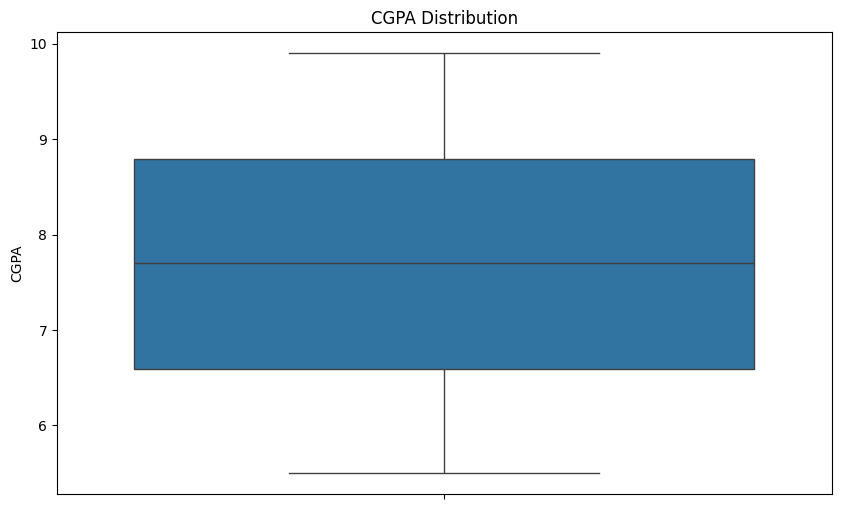

In [36]:
# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(y='CGPA', data=students_data)

plt.title('CGPA Distribution')
plt.ylabel('CGPA')
plt.show()

In [38]:
# Calculate Q1, Q3 and IQR
Q1 = students_data['CGPA'].quantile(0.25)
Q3 = students_data['CGPA'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 6.59
Q3: 8.79
IQR: 2.1999999999999993
Lower Limit: 3.290000000000001
Upper Limit: 12.089999999999998


In [39]:
outliers = students_data[(students_data['CGPA'] < lower_limit) | (students_data['CGPA'] > upper_limit)]

print("Number of Outliers:", len(outliers))
outliers

Number of Outliers: 0


,StudentID,RollNo,Name,Gender,DepartmentID,Batch,CGPA,Email,Phone


In [40]:
outliers[['StudentID', 'CGPA']]

,StudentID,CGPA


In [42]:
df_no_outliers = students_data[(students_data['CGPA'] >= lower_limit) & (students_data['CGPA'] <= upper_limit)]

print("Original Shape:", students_data.shape)
print("After Removing Outliers:", df_no_outliers.shape)

Original Shape: (20000, 9)
After Removing Outliers: (20000, 9)


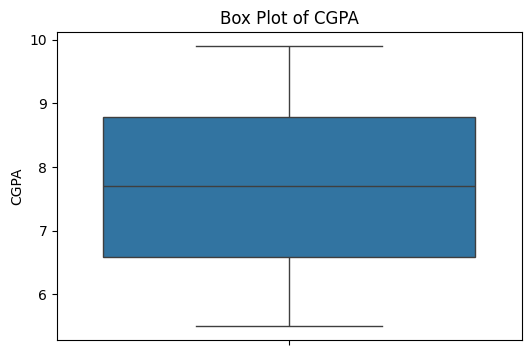

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(y=df_no_outliers['CGPA'])

plt.title("Box Plot of CGPA")
plt.ylabel("CGPA")

plt.show()